<a href="https://colab.research.google.com/github/luu-quang/Data_Mining_and_Machine_Learning_USTH/blob/Khanh/Val_result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_recall_curve, confusion_matrix, classification_report


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install display
import missingno as msno
import gc #để xoá object khỏi ram khi không cần nữa

from google.colab import drive
#drive ngáo lắm phải forece_remount
drive.mount("/content/drive", force_remount=True)
import shutil
import os
import pyarrow.parquet as pq
import pyarrow as pa

pd.set_option('display.max_columns', None)
if hasattr(pd, 'options'):
    pd.options.mode.copy_on_write = True  #chỉ tạo copy của dataframe khi có hành động write->kiểm soát số lượng copy

  Preparing metadata (setup.py) ... done
  Created wheel for display: filename=display-1.0.0-py3-none-any.whl size=1380 sha256=0dcac2b728bcb3300c0789ebc163b7e96a8fbf58e28d9b868041ad1f60b2a6d6
  Stored in directory: /root/.cache/pip/wheels/aa/37/3e/1ab7472ef100105e66476aec658aa95980b913260d4b48fcdc
Successfully built display
Mounted at /content/drive


In [ ]:
target = ["product_1","product_2",
              "product_3","product_4","product_5",
               "product_6","product_7","product_8","product_9","product_10","product_11",
               "product_12","product_13","product_14","product_15","product_16",
               "product_17","product_18","product_19","product_20","product_21",
               "product_22","product_23","product_24"]

In [ ]:
customer_info_cols = ['customer_code', 'employee_index', 'customer_country', 'sex', 'age',
       'new_index', 'seniority_months', 'primary_customer', 'month_start_type',
       'relation_type', 'residence_index', 'foreigner_index', 'join_channel',
       'province_code', 'activity_index', 'gross_househole_income', 'segment']

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_recall_curve, confusion_matrix, classification_report

binary_valid_parquet = "/content/drive/My Drive/bank_data/binary_valid.parquet"
binary_train_parquet = "/content/drive/My Drive/bank_data/binary_train.parquet"

df_train = pd.read_parquet(binary_train_parquet)
n_rows_merged = 183288456
n_1_merged = 309212
scale_pos_weight = (n_rows_merged - n_1_merged) / n_1_merged

nominal_cols = ['employee_index', 'relation_type', 'month_start_type', 'product']
nominal_categories = {}
ordinal_col = 'segment'
label_map = {'01 - TOP': 3, '02 - PARTICULARES': 2, '03 - UNIVERSITARIO': 1}

for col in nominal_cols:
  df_train[col] = df_train[col].astype(str)
  df_train[col] = df_train[col].astype('category')
  train_categories = df_train[col].cat.categories.to_list()
  train_codes = [i for i, cat in enumerate(train_categories)]
  nominal_categories[col] = (train_categories, train_codes)
del df_train
gc.collect()

0

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_recall_curve, confusion_matrix, classification_report

binary_valid_parquet = "/content/drive/My Drive/bank_data/binary_valid.parquet"

df_val = pd.read_parquet(binary_valid_parquet)
nominal_cols = ['employee_index', 'relation_type', 'month_start_type', 'product']
ordinal_col = 'segment'
label_map = {'01 - TOP': 3, '02 - PARTICULARES': 2, '03 - UNIVERSITARIO': 1}
df_val[ordinal_col] = df_val[ordinal_col].map(label_map)
df_val[ordinal_col] = df_val[ordinal_col].fillna(df_val[ordinal_col].mode()[0]).astype(np.int8)
df_val.drop(columns=['customer_code'], inplace=True)
for col in nominal_cols:
  df_val[col] = df_val[col].astype(str)
  df_val[col] = pd.Categorical(df_val[col], categories=nominal_categories[col][0], ordered=False)
  df_val[col] = df_val[col].astype('category')
X_val = df_val.drop(columns=['new_buy'])
y_val = df_val['new_buy']
dval = xgb.DMatrix(X_val, enable_categorical=True)
del df_val, X_val
gc.collect()

7

In [ ]:
best_model_path = "/content/drive/My Drive/bank_data/best_model.json"
best_model = xgb.Booster()
best_model.load_model(best_model_path)
y_pred = best_model.predict(dval)

In [ ]:
print(len(y_pred))
print(y_val.sum())
n_customer = len(y_pred) / 24
idx_list = []
for i in range(int(n_customer)):
  start = i*24
  end = start+24
  customer_probs = y_pred[start:end]
  top_probs_idx = np.argsort(-customer_probs)[:3]
  top_probs_idx = top_probs_idx + start
  idx_list.extend(top_probs_idx)
y_val_top = y_val[idx_list]
y_pred_top = y_pred[idx_list]

22260984
31952


In [52]:
print(len(y_val_top))
print(len(y_pred_top))
print(len(y_val_top) / y_val.sum())

2782623
2782623
87.08760015022534


Test data performance:
AUC-ROC: 0.9483
AUC-PR: 0.2444


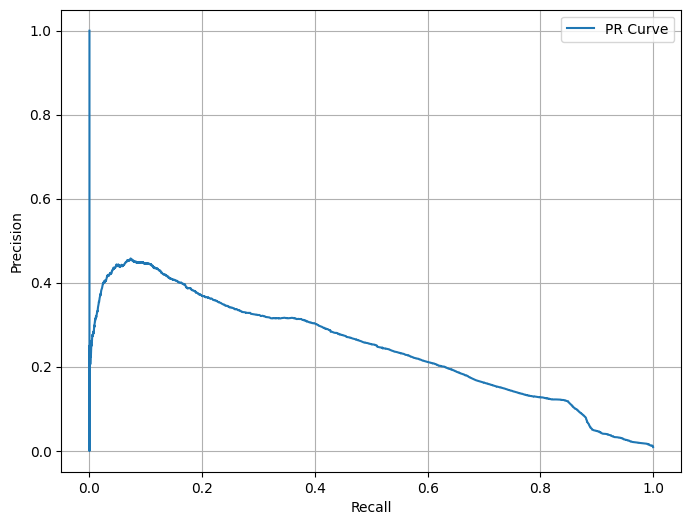

In [ ]:
auc_roc = roc_auc_score(y_val_top, y_pred_top)
auc_pr = average_precision_score(y_val_top, y_pred_top)
print(f"Test data performance:")
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR: {auc_pr:.4f}")

precisions, recalls, thresholds = precision_recall_curve(y_val_top, y_pred_top)
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='PR Curve')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [ ]:
f1_scores = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1])
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)

0.9999634


/tmp/ipykernel_4619/2842373482.py:1: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1])


In [ ]:
threshold = optimal_threshold
y_pred_top = (y_pred_top > threshold).astype(int)
print(classification_report(y_val_top, y_pred_top))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00   2758692
           1       0.00      0.00      0.00     23931

    accuracy                           0.99   2782623
   macro avg       0.50      0.50      0.50   2782623
weighted avg       0.98      0.99      0.99   2782623



In [ ]:
threshold = 0.996
y_pred_top_binary = (y_pred_top > threshold).astype(int)
print(classification_report(y_val_top, y_pred_top_binary))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98   2758692
           1       0.14      0.76      0.23     23931

    accuracy                           0.96   2782623
   macro avg       0.57      0.86      0.61   2782623
weighted avg       0.99      0.96      0.97   2782623



In [ ]:
print(confusion_matrix(y_val_top, y_pred_top_binary))

[[2645426  113266]
 [   5747   18184]]


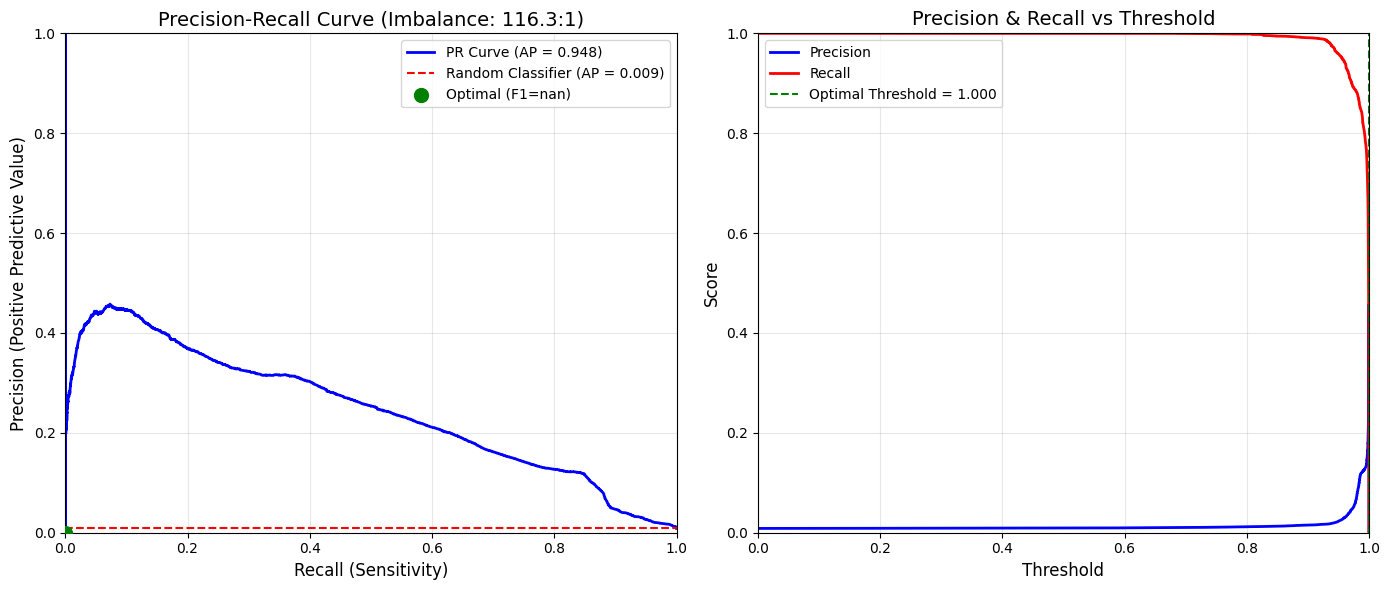

In [ ]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
baseline = y_val_top.mean()
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precisions[optimal_idx]
optimal_recall = recalls[optimal_idx]
# Plot 1: Precision-Recall Curve
ax1 = axes[0]
ax1.plot(recalls, precisions, 'b-', linewidth=2, label=f'PR Curve (AP = {auc_roc:.3f})')
ax1.axhline(y=baseline, color='r', linestyle='--', label=f'Random Classifier (AP = {baseline:.3f})')
ax1.scatter(optimal_recall, optimal_precision, color='green', s=100,
            zorder=5, label=f'Optimal (F1={optimal_f1:.3f})')
ax1.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax1.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax1.set_title(f'Precision-Recall Curve (Imbalance: {1/baseline:.1f}:1)', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# Plot 2: Precision and Recall vs Threshold
ax2 = axes[1]
ax2.plot(thresholds, precisions[:-1], 'b-', linewidth=2, label='Precision')
ax2.plot(thresholds, recalls[:-1], 'r-', linewidth=2, label='Recall')
ax2.axvline(x=optimal_threshold, color='green', linestyle='--',
            label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Precision & Recall vs Threshold', fontsize=14)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

n_products = 24
n_customers = len(y_pred) // n_products

hits = 0
positive_customers = 0

for i in range(n_customers):

    start = i * n_products
    end = start + n_products

    true_labels = y_val[start:end]
    pred_probs = y_pred[start:end]
    # skip customers with no positive product
    if true_labels.sum() == 0:
        continue

    positive_customers += 1

    top3_idx = np.argsort(-pred_probs)[:3]

    if true_labels.iloc[top3_idx].sum() > 0:
        hits += true_labels.iloc[top3_idx].sum()

recall_at_3 = hits / positive_customers

print("Recall@3:", recall_at_3)

Recall@3: 0.8248940057219676


In [ ]:
def average_precision_at_k(y_true, y_score, k=3):

    topk_idx = np.argsort(-y_score)[:k]

    y_true_topk = y_true.iloc[topk_idx]

    precisions = []
    num_hits = 0

    for i, rel in enumerate(y_true_topk, start=1):

        if rel == 1:
            num_hits += 1
            precisions.append(num_hits / i)

    if len(precisions) == 0:
        return 0.0

    return np.mean(precisions)


n_products = 24
n_customers = len(y_pred) // n_products

ap_scores = []

for i in range(n_customers):

    start = i * n_products
    end = start + n_products

    true_labels = y_val[start:end]
    pred_probs = y_pred[start:end]

    # optional: skip customers without positives
    if true_labels.sum() == 0:
        continue

    ap = average_precision_at_k(true_labels, pred_probs, k=3)

    ap_scores.append(ap)

map_at_3 = np.mean(ap_scores)

print("MAP@3:", map_at_3)

MAP@3: 0.6685337745452875


In [ ]:
import numpy as np

n_products = 24
n_customers = len(y_pred) // n_products

hits = 0
positive_customers = 0

for i in range(n_customers):

    start = i * n_products
    end = start + n_products

    true_labels = y_val[start:end]
    pred_probs = y_pred[start:end]
    # skip customers with no positive product
    if true_labels.sum() == 0:
        continue

    positive_customers += 1

    top3_idx = np.argsort(-pred_probs)[:3]

    if true_labels.iloc[top3_idx].sum() > 0:
        hits += 1

hit_rate_at_3 = hits / positive_customers

print("HitRate@3:", hit_rate_at_3)

HitRate@3: 0.7714659956568198
